In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv("../mizban_orders.csv")

In [4]:
X = df.drop(columns=["date", "orders", "completed_orders", "canceled_orders"])
y= df["orders"]

y.head(10)

0     95
1    110
2    150
3    165
4     90
5    100
6    105
7    115
8    130
9    170
Name: orders, dtype: int64

In [ ]:
def loss_function(X,y, m,b):
    
    X= np.array(X)
    y= np.array(y)

    prediction= np.dot(X , m) + b
    # mas = np.mean((y - prediction ) ** 2)
    total_mass= 0
    for i in range(len(y)):
      error = ((y - prediction) ** 2)  
      total_mass += error[i] 
    return total_mass / len(y)  
     

num_features = X.shape[1]
initial_m = np.zeros(num_features)
initial_b = 0
print(loss_function(X, y, initial_m, initial_b))
       

In [ ]:
def gradient_deccent(X,y, m_now ,b_now, alpha):
    
    m_gradient= 0
    b_gradient = 0
    
    for i in range(len(X)):
        f_wb= m_now * X[i] + b_now
        m_gradient += (1/len(X)) * (f_wb - y[i]) * X[i]
        b_gradient += (1/len(X)) * (f_wb - y[i]) 
        
    m =  m_now - (m_gradient * alpha) 
    b =  b_now - (b_gradient * alpha) 
    
    return m , b

print(gradient_deccent(X,y, 0.1, 0.2 , 0.001))

Epoch 0: w=[0.3373 0.345  0.4038 0.3426 0.345 ], b=1.4737, Loss=22831.5534
Epoch 200: w=[ 7.6708  6.4641 11.8224 13.1521  6.4641], b=127.8254, Loss=404.4664
Epoch 400: w=[ 7.3847  5.6139 12.7123 14.4992  5.6139], b=144.7539, Loss=24.5508
Epoch 600: w=[ 7.2714  5.2962 13.2898 14.6756  5.2962], b=147.0220, Loss=17.1987
Epoch 800: w=[ 7.1877  5.1275 13.7805 14.5506  5.1275], b=147.3259, Loss=16.7548
the result is:
Weights : [ 7.1031  5.0039 14.2407 14.3519  5.0039]
Bias (b): 147.3665

New Sample Data Input:
 weekday  is_weekend  active_users  restaurants  promotion
       6           1           600           25          1
Predicted Total Orders: 159.04



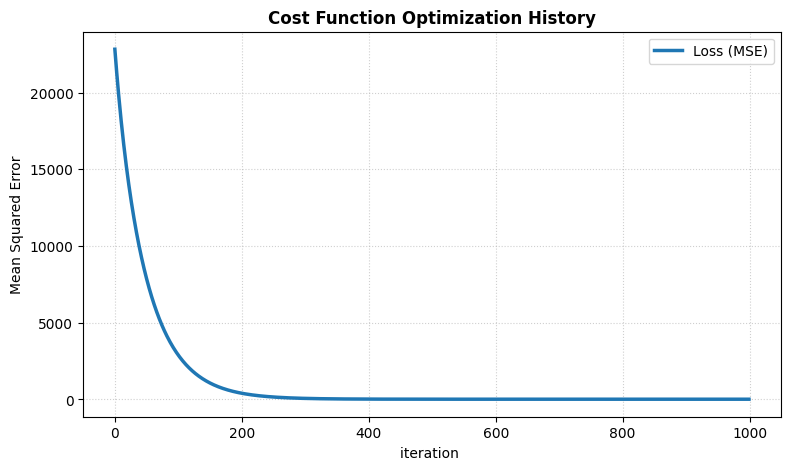

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = np.array((X - X_mean) / X_std)

def compute_loss(X, y, w, b):
    predictions = np.dot(X, w) + b
    mse = np.mean((predictions - y) ** 2)
    return mse

def gradient_descent(x, y, w_now, b_now, alpha=0.001):
    x_mat = np.array(x)
    y_vect = np.array(y)
    
    num_features = x_mat.shape[1]
    num_sample = len(y)
    
    w_gradient = np.zeros(num_features)
    b_gradient = 0.0
    
    for i in range(num_sample):
        f_wb = 0.0
        for j in range(num_features):
            f_wb += w_now[j] * x_mat[i][j]
        f_wb += b_now
        
        error = f_wb - y_vect[i]
        for j in range(num_features):
            w_gradient[j] += (1 / num_sample) * error * x_mat[i][j]
        
        b_gradient += (1 / num_sample) * error
        
    w = w_now - (alpha * w_gradient)              
    b = b_now - (alpha * b_gradient)
    
    return w, b              

num_feature = X_scaled.shape[1]
w = np.zeros(num_feature)
b = 0.0
alpha = 0.01  
iteration = 1000
loss_history = []

for i in range(iteration):
    w, b = gradient_descent(X_scaled, y, w, b, alpha)
    
    current_loss = compute_loss(X_scaled, y, w, b)
    loss_history.append(current_loss)
    
    if i % 200 == 0:
        print(f"Epoch {i}: w={np.round(w, 4)}, b={b:.4f}, Loss={current_loss:.4f}")
    
print(f"the result is:\nWeights : {np.round(w, 4)}\nBias (b): {b:.4f}\n")


new_data_point = pd.DataFrame([{
    "weekday": 6,
    "is_weekend": 1,
    "active_users": 600,
    "restaurants": 25,
    "promotion": 1
}])

new_data_scaled = np.array((new_data_point - X_mean) / X_std)


predicted_orders = np.dot(new_data_scaled, w) + b


print(len(predicted_orders))
print(f"New Sample Data Input:\n{new_data_point.to_string(index=False)}")
print(f"Predicted Total Orders: {predicted_orders[0]:.2f}\n")

plt.figure(figsize=(9, 5))
plt.plot(range(iteration), loss_history, color='#1f77b4', linewidth=2.5, label='Loss (MSE)')
plt.title('Cost Function Optimization History', fontsize=12, fontweight='bold')
plt.xlabel('iteration ', fontsize=10)
plt.ylabel('Mean Squared Error', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()


240
85


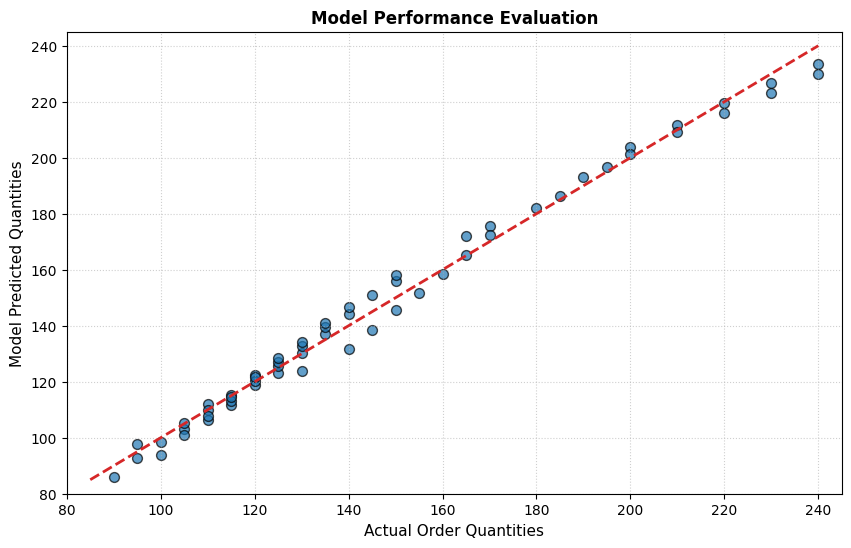

In [ ]:
all_predicted_orders = np.dot(X_scaled, w) + b

plt.figure(figsize=(10, 6))

plt.scatter(y, all_predicted_orders, color='#1f77b4', alpha=0.7, edgecolors='k', s=50, label='Data Days')

max_val = max(int(np.max(y)), int(np.max(all_predicted_orders)))
min_val = min(int(np.min(y)), int(np.min(all_predicted_orders)))

print(max_val)
print(min_val)

plt.plot([min_val, max_val], [min_val, max_val], color='#d62728', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Model Performance Evaluation', fontsize=12, fontweight='bold')
plt.xlabel('Actual Order Quantities', fontsize=11)
plt.ylabel('Model Predicted Quantities', fontsize=11)
plt.xlim(min_val - 5, max_val + 5)
plt.ylim(min_val - 5, max_val + 5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.show()